# Numerically solving the Schrodinger equation

In this assignment you will use [<tt>qmsolve</tt>](https://github.com/quantum-visualizations/qmsolve) to solve the time-independent Schrodinger equation in one dimension and plot the solutions.

### First, install <tt>qmsolve</tt> in one of two ways:
<ul>
    <li>From a <tt>unix</tt> command line, type <tt>pip install qmsolve</tt></li>
    <li>Put the following commands in a code cell in this notebook and execute:<br />
        <tt>import sys</tt><br />
        <tt>!{sys.executable} -m pip install qmsolve</tt></li>
</ul>

In [2]:
import sys
!{sys.executable} -m pip install qmsolve

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for progressbar: filename=progressbar-2.5-py3-none-any.whl size=12163 sha256=7002d38193451ab096d7b4865c3e044622b6f8a9efe6e2795d94dae132666c94
  Stored in directory: c:\users\btkai_0e62ja5\appdata\local\pip\cache\wheels\15\38\9d\0d335445b021c31266d906b07313cd961adc1e7cece18579e9
Successfully built progressbar

   -------------------- ------------------- 1/2 [qmsolve]
   ---------------------------------------- 2/2 [qmsolve]



### Homework problems:

<ol start=0>
    <li>Follow the link to the <tt>qmsolve</tt> GitHub page above. Click the link for the <tt>examples</tt> folder, then click on the <tt>eigenstate solver examples</tt> folder. Finally, click on <tt>1D_harmonic_oscillator.py</tt> to see a short code snippet that will calculate wavefunctions for a simple harmonic oscillator (SHO).</li>
    <li><tt>1D_harmonic_oscillator.py</tt> imports the <tt>Hamiltonian</tt> class from <tt>qmsolve</tt>. In quantum mechanics, what is a Hamiltonian? Please use multiple sources to formulate your answer and cite those sources. For this problem, crowd-sourced references such as Wikipedia and stackexchange are acceptable.</li>
    <li>Which force law is defined in the function <tt>harmonic_oscillator()</tt> in cell 2 of this notebook?</li>
    <li>What are the eigenstates referred to in lines 22 and 23 in <tt>1D_harmonic_oscillator.py</tt>? Again, please use multiple sources to formulate your answer and cite those sources.
    <li>Code cells 1 and 2 below contain imported code from <tt>1D_harmonic_oscillator.py</tt>, including a visualization of eigenstate 0 of the SHO. In subsequent code cells, plot any five SHO eigenstates of your choice.</li>
</ol>

Note: you can write your answers to the non-code problems in a markdown cell. From within a new notebook cell, click the box with the downward-pointing arrow that says "Code" (on your Jupyter toolbar) and change to "Markdown". Then you can just type in the cell like a regular text file.

Answers: 

1) In quantum mechanics, the Hamiltonian is the operator that represents the total energy of a system. It contains both the kinetic energy and the potential energy of the particle. The Hamiltonian is extremely important because solving the Schrödinger equation with the Hamiltonian gives the allowed energy levels and wave functions of the system. Sources: https://en.wikipedia.org/wiki/Hamiltonian_(quantum_mechanics), https://physics.stackexchange.com/questions/488218/what-is-a-hamiltonian-of-a-system
2) The function defines Hooke’s Law, which is the restoring force law for a simple harmonic oscillator.
3) The eigenstates are the allowed stationary quantum states of the system. When the Hamiltonian is solved, the Schrödinger equation produces discrete energy values called eigenvalues and corresponding wave functions called eigenstates. Each eigenstate has a definite energy associated with it. For the harmonic oscillator, the eigenstates correspond to the quantized vibrational states. The eigenstates are special because measuring the energy of a particle in one of these states always gives the same energy value. Sources: https://en.wikipedia.org/wiki/Eigenvalues_and_eigenvectors, https://phys.libretexts.org/Bookshelves/Quantum_Mechanics/Introductory_Quantum_Mechanics_(Fitzpatrick)/03%3A_Fundamentals_of_Quantum_Mechanics/3.08%3A_Eigenstates_and_Eigenvalues

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from qmsolve import Hamiltonian, SingleParticle, init_visualization, Å, eV

Computing...
Took 0.08643984794616699
[ 13.8243627   41.46350403  69.08346722  96.68423227 124.26577906
 151.82808744 179.37113718 206.89490797 234.39937941 261.8845311
 289.350386   316.7967421  344.22386048 371.63152855 399.01978706
 426.38935398 453.73700627 481.07455407 508.37059293 535.66904608
 562.94001038 590.19183732 617.42481756 644.63569509 671.82965019
 699.00231564 726.15591894 753.28933246 780.42109633 807.59063544]


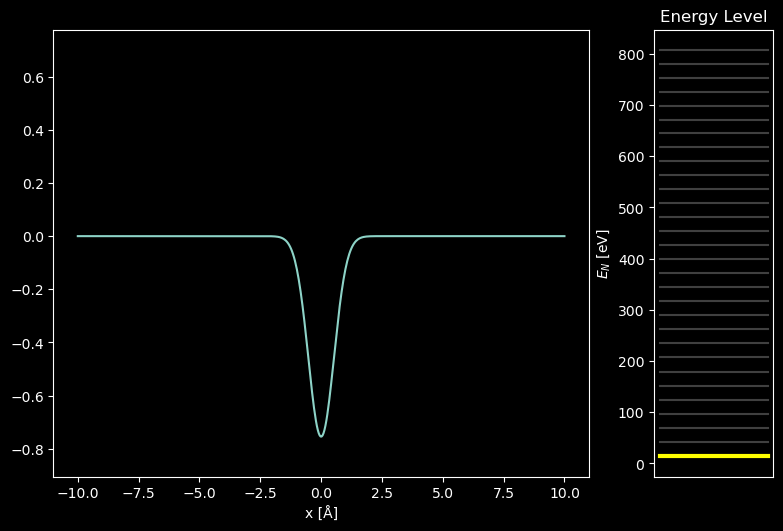

In [4]:
# Harmonic oscillator potential
def harmonic_oscillator(particle):
    k = 100 * eV / Å**2
    return 0.5 * k * particle.x**2

# Define the Hamiltonian
H = Hamiltonian(particles = SingleParticle(), potential = harmonic_oscillator, 
                spatial_ndim = 1, N = 512, extent = 20*Å)

#Diagonalize the Hamiltonian and compute the eigenstates
eigenstates = H.solve(max_states = 30)

# Print out the energies of the eigenstates
print(eigenstates.energies) # the printed energies are expressed in eV

# Visualize the Eigenstates
visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(0)

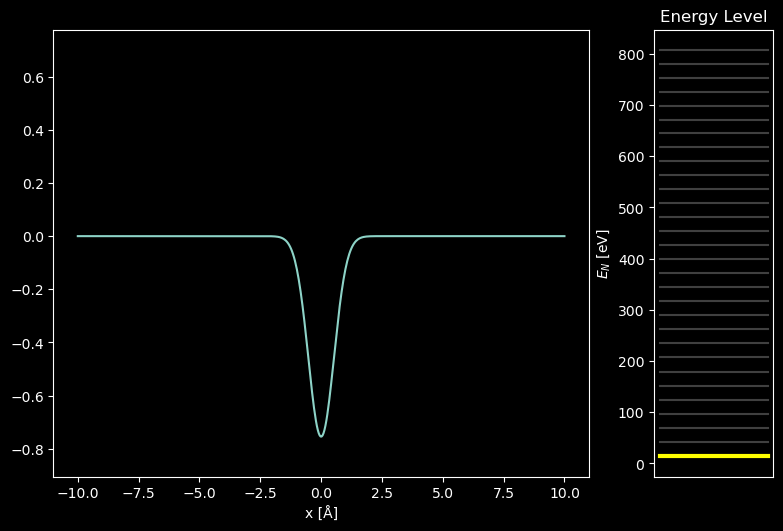

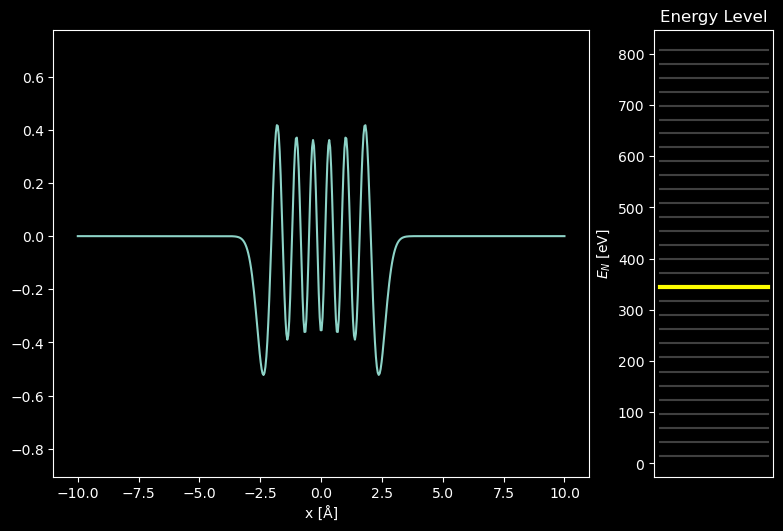

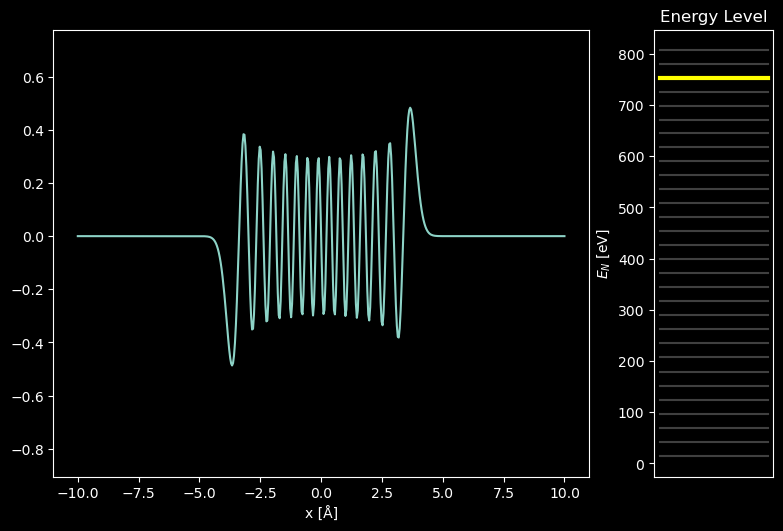

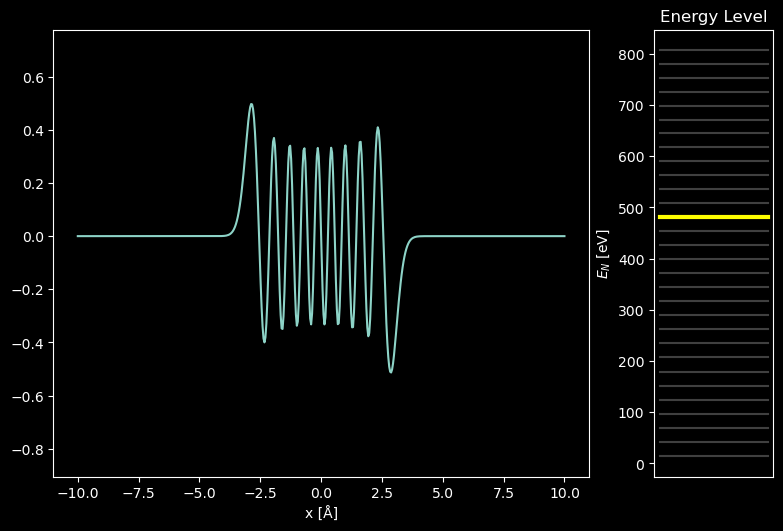

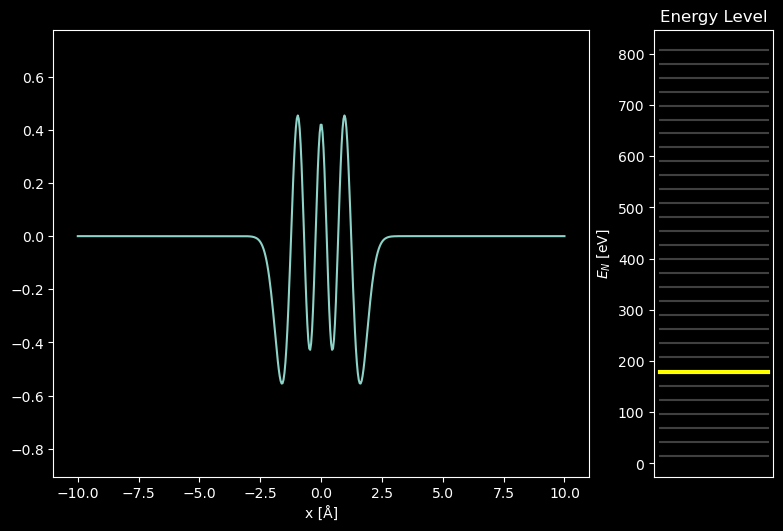

In [5]:
visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(0)
visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(12)
visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(27)
visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(17)
visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(6)

<ol start=5>
    <li>What is on the x-axis of your plots?</li>
    <li>Are your plots showing wave functions $\psi(x)$ or probability functions $\psi^*(x) \psi(x)$? How do you know?</li>
</ol>

### New potential: infinite square well

Below I define the infinite square well potential for $L = 8$ Angstroms and plot the two lowest-energy eigenstates (compare to Figure 6.3 in your textbook).

Answers:

5) The x-axis represents the position of the particle, x, measured in Angstroms (Å). This is because the Hamiltonian is defined in one spatial dimension and the potential depends on the particle’s position. The extent = 20*Å parameter sets the spatial range over which the wave functions are calculated.
6) The plots are showing the wave functions ψ(x), not the probability densities. We know this because the plotted curves contain both positive and negative values. A probability density,∣ψ(x)∣^2 can never be negative since it is the square magnitude of the wave function.

Computing...
Took 0.07109713554382324
[  0.58920993   2.35288818   5.32922378   9.4276143   14.7299955
  21.21004635  28.8673845   37.70155819  47.71204619  58.89825789
  71.2595333   84.79514312  99.50428872 115.38610229 132.4396589
 150.66390045 170.05783494 190.62025981 212.34997487 235.24600915
 259.30573305 284.52968954 310.91508872 338.46067671 367.16478402
 397.02581864 428.04195078 460.21237484 493.53156504 528.00178985]


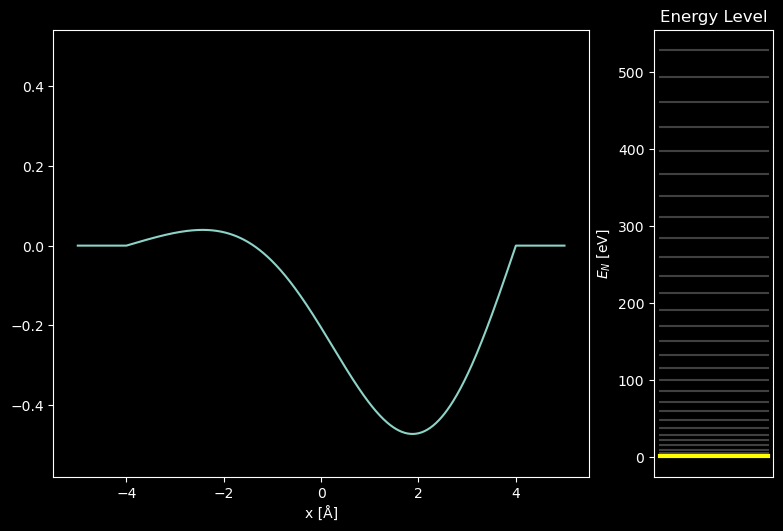

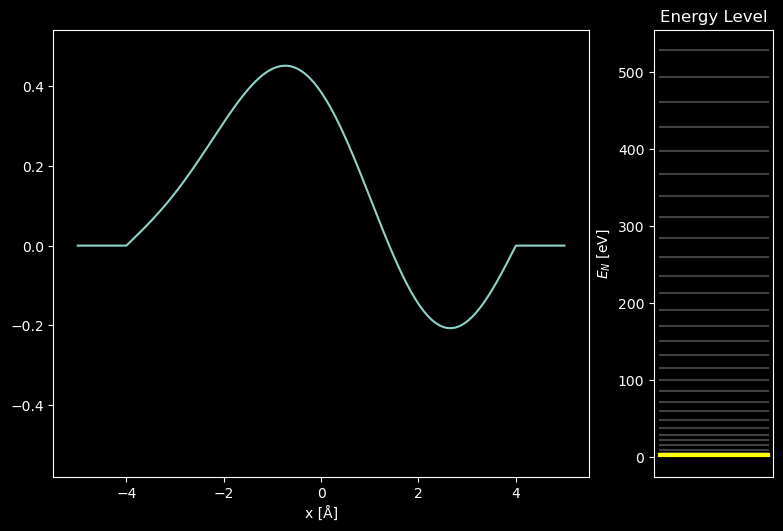

In [6]:
# 8 angstrom-wide infinite square well
def infinite_square_well(particle):
    potential = np.zeros_like(particle.x)
    out_of_bounds = np.abs(particle.x) > 4*Å
    potential[out_of_bounds] = np.inf
    return potential

# Define the Hamiltonian of the infinite square well
H_sw = Hamiltonian(particles = SingleParticle(), potential = infinite_square_well, 
                   spatial_ndim = 1, N = 512, extent = 10*Å)

# Diagonalize the Hamiltonian and compute the eigenstates
eigenstates_sw = H_sw.solve(max_states = 30)

print(eigenstates_sw.energies)

# Visualize the infinite square well eigenstates
visualization_sw = init_visualization(eigenstates_sw)
visualization_sw.plot_eigenstate(0)
visualization_sw.plot_eigenstate(1)

<ol start=7>
    <li>Plot any three infinite square well eigenstates of your choice.</li>
    <li>What property do the infinite square well eigenstates have that's different than the SHO eigenstates? (Hint: think about the properties of valid wave functions we discussed in class)</li>
    <li>What is the relationship between the number of extrema (maxima plus minima) in each eigenstate plot and the quantum number of the eigenstate?</li>
</ol>

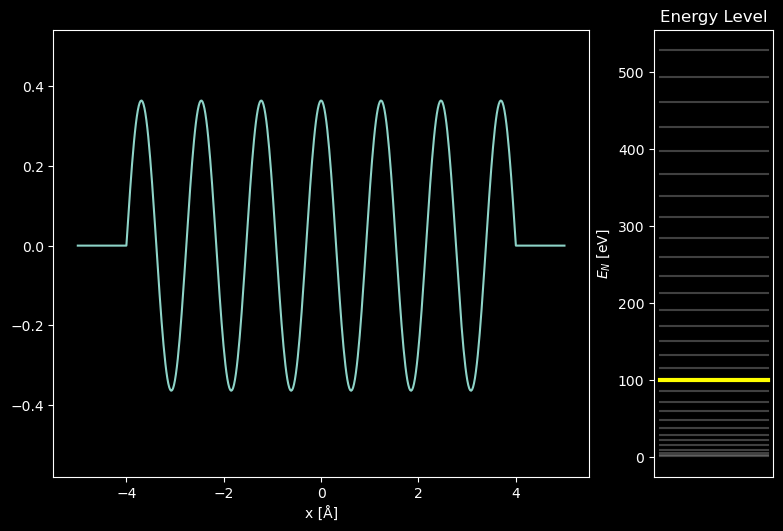

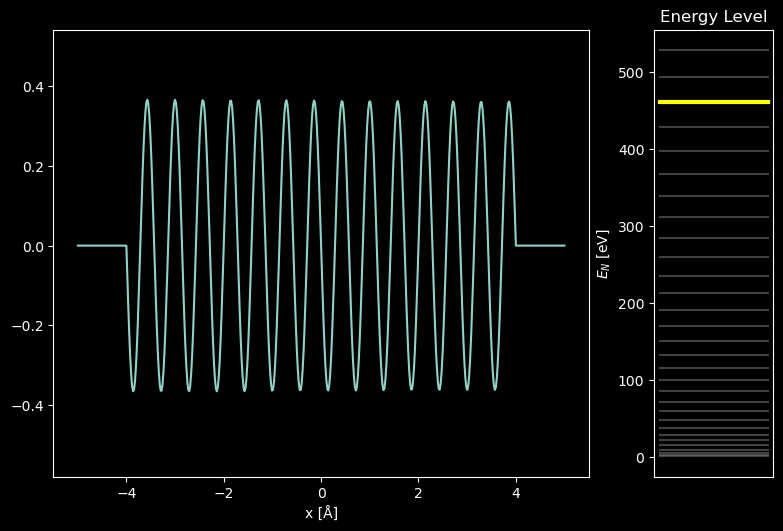

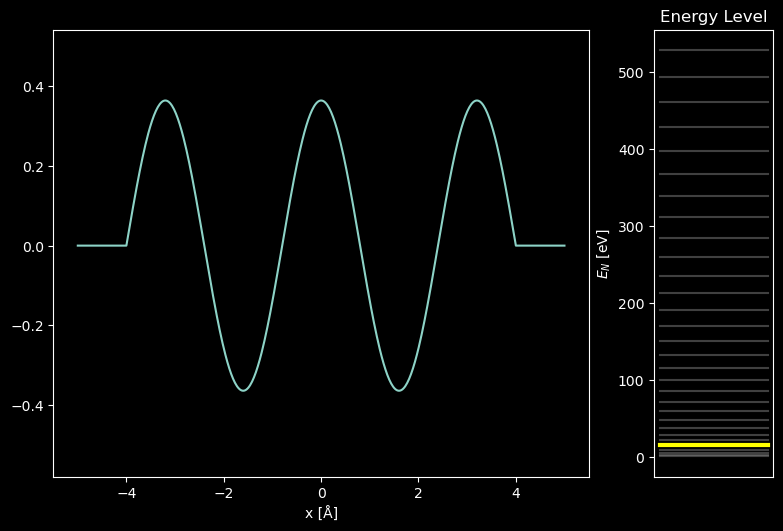

In [7]:
visualization_sw.plot_eigenstate(12)
visualization_sw.plot_eigenstate(27)
visualization_sw.plot_eigenstate(4)

Answers: 

8) The infinite square well eigenstates are exactly zero at the boundaries of the well. This happens because the potential becomes infinite outside the box, so the particle cannot exist there. Therefore the wave function must satisfy the boundary conditions ψ(−L/2)=0 and ψ(L/2)=0. The SHO eigenstates are different because the harmonic oscillator potential is finite everywhere. The SHO wave functions extend outward indefinitely and only approach zero asymptotically. Another important difference is that the infinite square well wave functions are strictly confined to a finite region, while the SHO wave functions extend across all space.
9) As the quantum number increases, the number of extrema increases. For the infinite square well, the n=1 state has 1 extremum, the n=2 state has 2 extrema, and the n=3 state has 3 extrema. In general the number of extrema=n. Higher-energy states oscillate more rapidly, producing more maxima and minima.

### Now it's your turn to define a potential

<ol start=10>
    <li>Write a function that defines a <em>finite square-well</em> potential (textbook section 5.4). You can choose the width of the well in Angstroms and the potential at the walls in eV. Calculate the finite square-well Hamiltonian and plot any five eigenstates you choose.</li>
    <li>Based on your plots, do you think a particle can get out of the finite square-well potential no matter its quantum number $n$?</li>
</ol>

Computing...
Took 0.010565757751464844


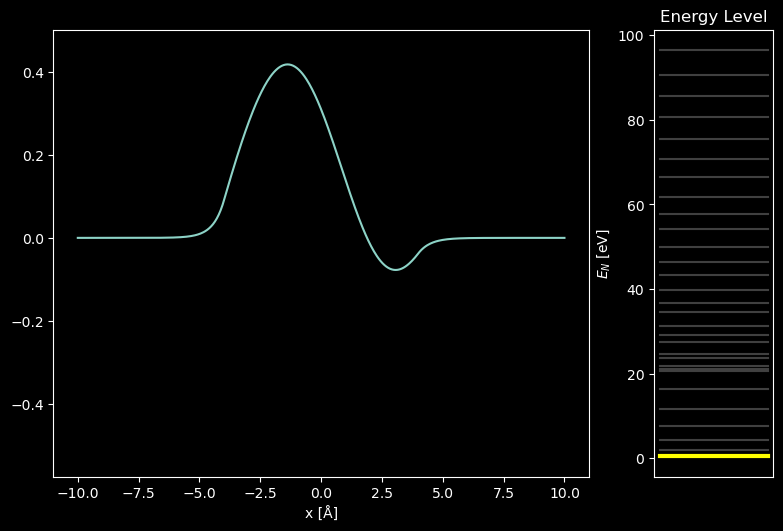

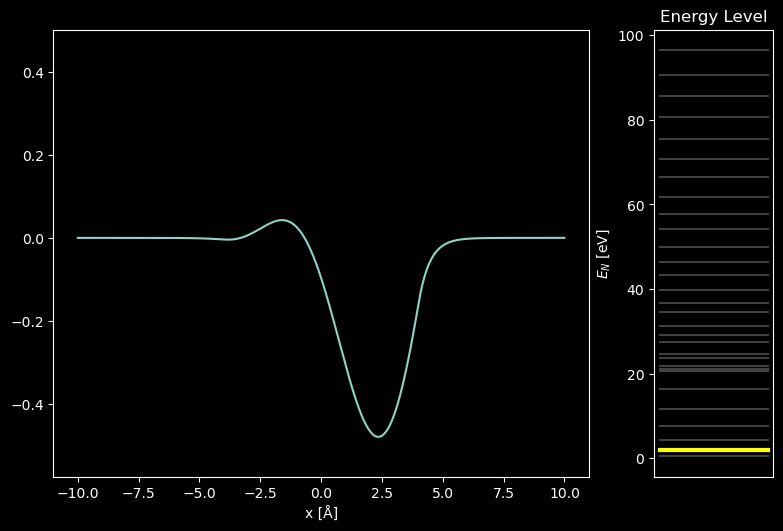

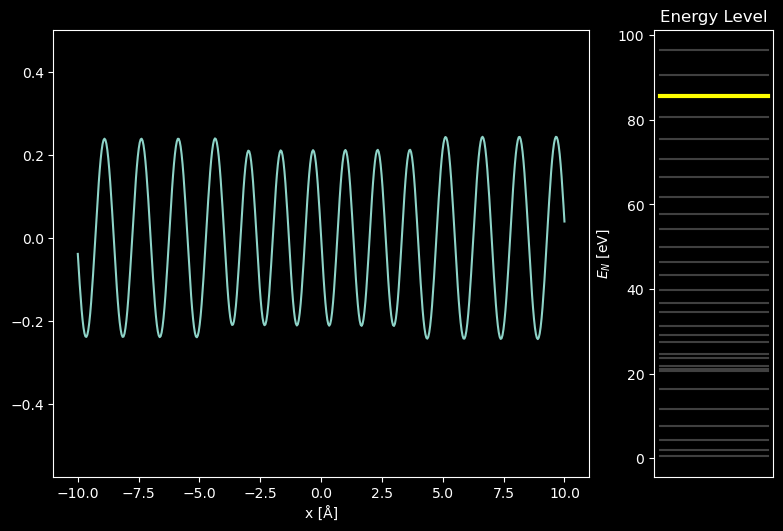

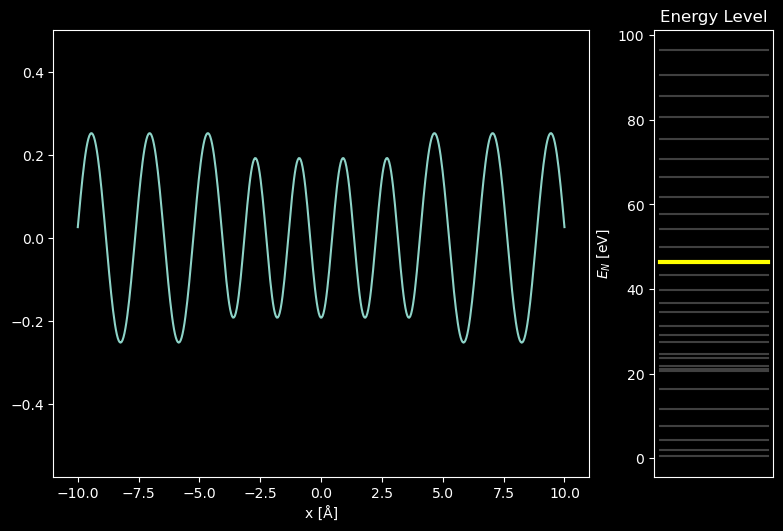

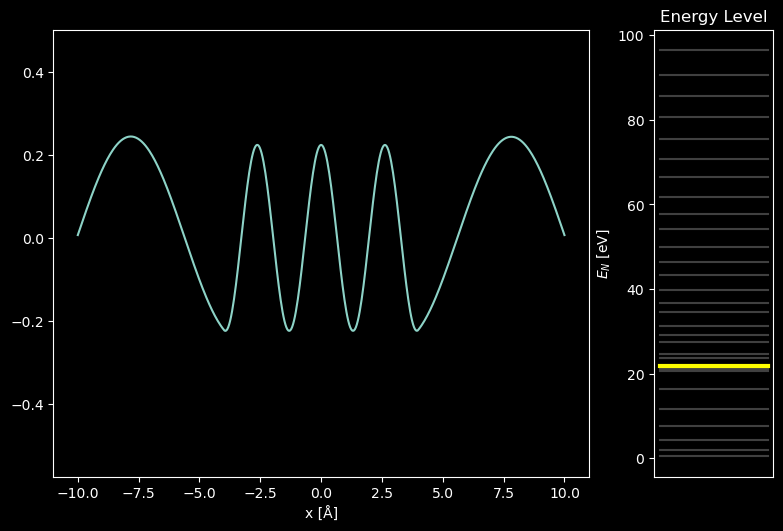

In [10]:
def finite_square_well(particle):
    V0 = 20 * eV
    width = 8 * Å

    potential = np.full_like(particle.x, V0)

    inside = np.abs(particle.x) < width/2
    potential[inside] = 0

    return potential

H_finite = Hamiltonian(
    particles = SingleParticle(),
    potential = finite_square_well,
    spatial_ndim = 1,
    N = 512,
    extent = 20*Å
)

finite_states = H_finite.solve(max_states = 30)


visualization_finite = init_visualization(finite_states)

visualization_finite.plot_eigenstate(0)
visualization_finite.plot_eigenstate(1)
visualization_finite.plot_eigenstate(27)
visualization_finite.plot_eigenstate(18)
visualization_finite.plot_eigenstate(8)

Answers: 

11) Yes. Unlike the infinite square well, the walls of a finite square well are not infinitely high. Because of this, the wave functions extend slightly into the classically forbidden region outside the well. This means there is always a nonzero probability of finding the particle outside the well.